<a href="https://colab.research.google.com/github/junaidshaikh2004/AIDS_Sem8_RL/blob/main/RL_Exp_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Junaid Shaikh | 221A052 |48

---



Junaid Shaikh - 221A052


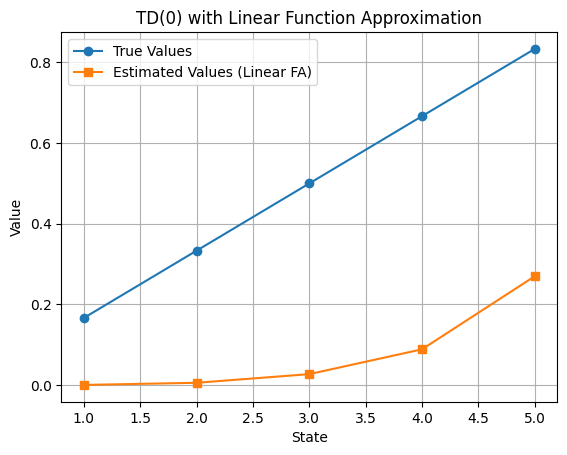

In [1]:
print("Junaid Shaikh - 221A052")
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n_states = 5
alpha = 0.01
gamma = 1.0
episodes = 100

# Feature representation (one-hot encoding)
def state_features(state):
    feature = np.zeros(n_states)
    if 1 <= state <= n_states:
        feature[state - 1] = 1
    return feature

# True state values
true_value = np.array([1/6, 2/6, 3/6, 4/6, 5/6])

# Initialize weights
w = np.zeros(n_states)

# Training loop
for ep in range(episodes):
    state = 3  # start from middle

    while True:
        # Random walk: left or right
        next_state = state + np.random.choice([-1, 1])

        # Reward
        if next_state == 6:
            reward = 1.0
        else:
            reward = 0.0

        # Feature vectors
        x = state_features(state)
        x_next = state_features(next_state)

        # Value estimates
        v = np.dot(w, x)
        v_next = np.dot(w, x_next) if 1 <= next_state <= 5 else 0

        # TD(0) update
        td_error = reward + gamma * v_next - v
        w += alpha * td_error * x

        # Terminal condition
        if next_state == 0 or next_state == 6:
            break

        state = next_state

# Estimated values
estimated_values = w.copy()

# Plot results
plt.plot(range(1, 6), true_value, marker='o', label='True Values')
plt.plot(range(1, 6), estimated_values, marker='s', label='Estimated Values (Linear FA)')
plt.xlabel('State')
plt.ylabel('Value')
plt.title('TD(0) with Linear Function Approximation')
plt.legend()
plt.grid()
plt.show()